In [ ]:
!pip install wandb

In [ ]:
!wandb login --relogin

wandb: WARNING Using legacy-service, which is deprecated. If this is unintentional, you can fix it by ensuring you do not call `wandb.require('legacy-service')` and do not set the WANDB_X_REQUIRE_LEGACY_SERVICE environment variable.
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Полносвязная модель

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

df = pd.read_csv('output21k.csv')

data = df.copy()


split_index = int(len(data['Time'])*0.7)
valid_index = int((len(data['Time']) - split_index)*0.5)

df[['hours', 'minutes', 'seconds']] = df['Time'].str.split(':', expand=True).astype(int)
df['Time'] = (
    df['hours'] * 60 +
    df['minutes'] +
    df['seconds']
)

data['Time'] = df['Time']
data = data.values.tolist()

data = np.array(data)
#print(data)
scaler = StandardScaler()

# Нормализация данных
data = scaler.fit_transform(data)

# преобразование в тензор
data = torch.tensor(data, dtype=torch.float32)


X_train = data[:split_index]
y_train = data[1:split_index + 1]
X_valid = data[split_index : split_index + valid_index]
y_valid = data[split_index + 1: split_index + valid_index + 1]
X_test = data[split_index + valid_index : len(data) - 1]
y_test = data[split_index + valid_index + 1 : len(data)]


# Создаем Dataset и DataLoader
dataset = TensorDataset(X_train, y_train)
batch_size = 16  # Размер батча
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

dataset_valid = TensorDataset(X_valid, y_valid)
dataloader_valid = DataLoader(dataset_valid, batch_size=batch_size, shuffle=False)

dataset_test = TensorDataset(X_test, y_test)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)


In [ ]:
print(f"X_test shape: {X_test.shape}")  # Должно быть (n_samples, 3, 4)
print(f"y_test shape: {y_test.shape}")  # Должно быть (n_samples, 4)

X_test shape: torch.Size([3225, 3, 4])
y_test shape: torch.Size([3225, 4])


In [ ]:

for batch_X, batch_y in dataloader:
    print(batch_y[:,1])
    break

tensor([1.6254, 1.6254, 1.6254, 1.6254, 1.6254, 1.6254, 1.6254, 1.6254, 1.6297,
        2.0883, 2.1276, 2.2142, 0.8157, 0.3379, 0.2798, 0.3701])


In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error

class Linear(nn.Module):
    def __init__(self, input_dim, hiden_input):
        super(Linear, self).__init__()

        self.linear1 = nn.Linear(input_dim, hiden_input)
        self.F = nn.ReLU()
        self.linear2 = nn.Linear(hiden_input, 2)


    def forward(self, x):
        prediction = self.linear2(self.F(self.linear1(x)))  # Форма: (batch_size, 1)

        return prediction


def masked_mse_loss(predictions, targets):
    #loss_1 = torch.nn.functional.mse_loss(predictions[0], targets[0])
    #loss_2 = torch.nn.functional.mse_loss(predictions[1:5], targets[1:5])
    # Loss для первого признака (индекс 0)
    loss_1 = torch.nn.functional.mse_loss(predictions[:, 0], targets[:, 0])

    # Loss для признаков 2–4 (индексы 1:4)
    loss_2 = torch.nn.functional.mse_loss(predictions[:, 1:2], targets[:, 1:2])
    if loss_1 + loss_2 < 1e-6:
        return 1e-6
    return (loss_1 + loss_2)/2

def mse_loss(predictions, targets):

    # Loss для первого признака (индекс 0)
    mse_time = torch.sqrt(torch.nn.functional.mse_loss(predictions[:, 0], targets[:, 0]))

    # Loss для признаков 2–4 (индексы 1:4)
    mse_value = torch.sqrt(torch.nn.functional.mse_loss(predictions[:, 1], targets[:, 1]))

    return mse_time, mse_value

In [ ]:
import wandb

# Инициализация W&B (в начале скрипта)
wandb.init(project="progon_with_loss", config={
    "input_dim": 4,
    "hidden_dim": 100,
    "lr": 0.001,
    "batch_size": 16
})

best_val_loss = float('inf')

# Параметры модели
input_dim = 4  # 4 измерения
hiden_dim = 100
model = Linear(input_dim, hiden_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 125
for epoch in range(num_epochs):
    model.train()  # Режим обучения
    epoch_loss = 0.0  # Для накопления лосса за эпоху
    all_gradients = []
    all_weights = []

    for batch_X, batch_y in dataloader:
        # Очищаем градиенты перед каждым батчем
        optimizer.zero_grad()

        # Forward pass
        predictions = model(batch_X)  # Добавляем временную размерность


        # Вычисляем лосс
        loss = masked_mse_loss(predictions, batch_y)

        # Backward pass (вычисляем градиенты)
        loss.backward()

        # Собираем градиенты для текущего батча
        gradients = [p.grad.view(-1) for p in model.parameters() if p.grad is not None]
        all_gradients.extend(gradients)

        # Обновляем параметры модели
        optimizer.step()

        # Собираем веса после обновления
        weights = [p.data.view(-1) for p in model.parameters()]
        all_weights.extend(weights)

        # Накопление лосса
        epoch_loss += loss.item()

    # Логирование средних значений по эпохе
    wandb.log({
        "train_loss": epoch_loss / len(dataloader),
        "learning_rate": optimizer.param_groups[0]['lr'],
        "gradients": wandb.Histogram(torch.cat(all_gradients).cpu().numpy()),
        "weights": wandb.Histogram(torch.cat(all_weights).cpu().numpy())
    })

    # Средний лосс за эпоху
    avg_epoch_loss = epoch_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}")
    # Проверка на переобучение каждые 15 эпох
    if (epoch + 1) % 15 == 0:
        model.eval()  # Режим оценки
        valid_loss = 0.0

        # Отключаем вычисление градиентов для валидации
        with torch.no_grad():
            for batch_X, batch_y in dataloader_valid:
                # Forward pass
                #predictions = model(batch_X.unsqueeze(1))
                #predictions = predictions.squeeze(1)
                predictions = model(batch_X)
                #print("Размер predictions:", predictions.shape)
                #print("Размер batch_X:", batch_X.shape)
                #print("Размер batch_y:", batch_y.shape)

                # Вычисляем лосс
                loss = masked_mse_loss(predictions, batch_y)
                valid_loss += loss.item()

        # Средний лосс на валидационных данных
        avg_valid_loss = valid_loss / len(dataloader_valid)

        # Сохраняем модель при улучшении валидационного лосса
        if avg_valid_loss < best_val_loss:
            best_val_loss = avg_valid_loss
            torch.save(model.state_dict(), "best_model.pth")
            wandb.save("best_model_linear.pth")  # Автоматическая загрузка в W&B

        wandb.log({"val_loss": avg_valid_loss})

        print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {avg_valid_loss:.4f}")

        # Возвращаем модель в режим обучения
        model.train()



Epoch [1/125], Loss: 0.2761
Epoch [2/125], Loss: 0.2419
Epoch [3/125], Loss: 0.2336
Epoch [4/125], Loss: 0.2270
Epoch [5/125], Loss: 0.2220
Epoch [6/125], Loss: 0.2178
Epoch [7/125], Loss: 0.2143
Epoch [8/125], Loss: 0.2113
Epoch [9/125], Loss: 0.2087
Epoch [10/125], Loss: 0.2064
Epoch [11/125], Loss: 0.2045
Epoch [12/125], Loss: 0.2030
Epoch [13/125], Loss: 0.2016
Epoch [14/125], Loss: 0.2005
Epoch [15/125], Loss: 0.1995
Epoch [15/125], Validation Loss: 0.1966
Epoch [16/125], Loss: 0.1987
Epoch [17/125], Loss: 0.1981
Epoch [18/125], Loss: 0.1975
Epoch [19/125], Loss: 0.1970
Epoch [20/125], Loss: 0.1965
Epoch [21/125], Loss: 0.1961
Epoch [22/125], Loss: 0.1957
Epoch [23/125], Loss: 0.1954
Epoch [24/125], Loss: 0.1951
Epoch [25/125], Loss: 0.1948
Epoch [26/125], Loss: 0.1945
Epoch [27/125], Loss: 0.1943
Epoch [28/125], Loss: 0.1941
Epoch [29/125], Loss: 0.1939
Epoch [30/125], Loss: 0.1937
Epoch [30/125], Validation Loss: 0.1907
Epoch [31/125], Loss: 0.1935
Epoch [32/125], Loss: 0.1933
E

In [ ]:

model.eval()
test_loss = 0.0
time_loss, value_loss = 0.0, 0.0
with torch.no_grad():
    for batch_X, batch_y in dataloader_test:
        predictions = model(batch_X)
        loss = masked_mse_loss(predictions, batch_y)
        current_time_loss, current_value_loss = mse_loss(predictions, batch_y)
        test_loss += loss.item()
        time_loss += current_time_loss
        value_loss += current_value_loss


avg_test_loss = test_loss / len(dataloader_test)
avg_time_loss = time_loss / len(dataloader_test)
avg_value_loss = value_loss / len(dataloader_test)

# Логируем тестовый лосс в W&B
wandb.log({"test_loss": avg_test_loss,
    "test_time_loss": avg_time_loss,
    "test_sugar_loss": avg_value_loss})

print(f"Test loss: {avg_test_loss}")

# Обязательно завершаем сессию W&B в конце
wandb.finish()



Test loss: 0.17784646244277016


learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_loss,▁
test_sugar_loss,▁
test_time_loss,▁
train_loss,█▆▆▄▄▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▃▂▂▁▁▁
learning_rate,0.001
test_loss,0.17785
test_sugar_loss,0.43583
test_time_loss,0.30621
train_loss,0.1869


RMTPP

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

# Загрузка данных
df = pd.read_csv('output21k.csv')

# Преобразование времени
df[['hours', 'minutes', 'seconds']] = df['Time'].str.split(':', expand=True).astype(int)
df['Time'] = df['hours'] * 60 + df['minutes'] + df['seconds']

# Выбор признаков и нормализация
features = df.drop(columns=['hours', 'minutes', 'seconds']).values
print(features[4:33])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Параметры последовательности
seq_length = 3 # Длина временного окна
batch_size = 32

# Создание последовательностей
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length-1):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_features, seq_length)

# Разделение на train/valid/test
train_size = int(0.7 * len(X))
valid_size = int(0.15 * len(X))
test_size = len(X) - train_size - valid_size

X_train, y_train = X[:train_size], y[:train_size]
X_valid, y_valid = X[train_size:train_size+valid_size], y[train_size:train_size+valid_size]
X_test, y_test = X[train_size+valid_size:], y[train_size+valid_size:]

# Преобразование в тензоры PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_valid = torch.FloatTensor(X_valid)
y_valid = torch.FloatTensor(y_valid)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

# Создание DataLoader
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)

valid_data = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)

test_data = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

[[5.02000000e+02 1.49020000e+02 0.00000000e+00 1.39355889e-02]
 [6.34000000e+02 1.49020000e+02 0.00000000e+00 1.39355889e-02]
 [7.20000000e+02 1.49020000e+02 0.00000000e+00 1.39355889e-02]
 [8.22000000e+02 1.49020000e+02 0.00000000e+00 1.39355889e-02]
 [8.65000000e+02 1.49020000e+02 2.10000000e+00 1.88935589e-01]
 [8.90000000e+02 1.49109012e+02 3.98000000e+01 3.33060226e+00]
 [9.46000000e+02 1.58698373e+02 0.00000000e+00 1.39355889e-02]
 [9.50000000e+02 1.59518928e+02 0.00000000e+00 1.39355889e-02]
 [9.63000000e+02 1.61330835e+02 0.00000000e+00 1.39355889e-02]
 [1.08800000e+03 1.32089630e+02 0.00000000e+00 1.39355889e-02]
 [1.13500000e+03 1.22098022e+02 2.30000000e+01 1.93060226e+00]
 [1.17400000e+03 1.20884642e+02 0.00000000e+00 1.39355889e-02]
 [1.19000000e+03 1.22772304e+02 0.00000000e+00 1.39355889e-02]
 [1.20500000e+03 1.24439035e+02 6.88000000e+01 5.74726892e+00]
 [1.21800000e+03 1.25802714e+02 0.00000000e+00 1.39355889e-02]
 [1.31000000e+03 1.46260677e+02 2.33000000e+01 1.955602

In [ ]:
!pip install --force-reinstall torch==2.0.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
for batch_X, batch_y in train_loader:
    t=scaler.inverse_transform(batch_y.cpu().tolist())
    batch_y[:,0]+=0.17
    batch_y[:,1]+=0.17
    p=scaler.inverse_transform(batch_y.cpu().tolist())
    print(t,p,sep='\n\n')
    break

[[ 4.32000009e+02  1.49019999e+02 -1.08626566e-08  1.39355760e-02]
 [ 5.02000000e+02  1.49019999e+02 -1.08626566e-08  1.39355760e-02]
 [ 6.34000003e+02  1.49019999e+02 -1.08626566e-08  1.39355760e-02]
 [ 7.20000000e+02  1.49019999e+02 -1.08626566e-08  1.39355760e-02]
 [ 8.21999994e+02  1.49019999e+02 -1.08626566e-08  1.39355760e-02]
 [ 8.65000006e+02  1.49020001e+02  2.10000014e+00  1.88935582e-01]
 [ 8.89999994e+02  1.49109012e+02  3.98000010e+01  3.33060233e+00]
 [ 9.45999994e+02  1.58698375e+02 -1.08626566e-08  1.39355760e-02]
 [ 9.50000002e+02  1.59518927e+02 -1.08626566e-08  1.39355760e-02]
 [ 9.63000004e+02  1.61330833e+02 -1.08626566e-08  1.39355760e-02]
 [ 1.08800001e+03  1.32089629e+02 -1.08626566e-08  1.39355760e-02]
 [ 1.13499997e+03  1.22098022e+02  2.29999998e+01  1.93060228e+00]
 [ 1.17399998e+03  1.20884642e+02 -1.08626566e-08  1.39355760e-02]
 [ 1.19000001e+03  1.22772304e+02 -1.08626566e-08  1.39355760e-02]
 [ 1.20500002e+03  1.24439035e+02  6.88000017e+01  5.74726880e

In [ ]:
print(scaled_features, end='\n\n')
print(scaled_features[0:4])

[[-0.80135206  1.62544554 -0.41411731 -0.41589828]
 [-0.68390433  1.62544554 -0.41411731 -0.41589828]
 [-0.66041478  1.62544554 -0.41411731 -0.41589828]
 ...
 [-0.5194775  -1.2541069  -0.41411731 -0.41589828]
 [-0.30807159 -0.41634007 -0.41411731 -0.41589828]
 [-0.20941549 -0.05376118 -0.41411731 -0.41589828]]

[[-0.80135206  1.62544554 -0.41411731 -0.41589828]
 [-0.68390433  1.62544554 -0.41411731 -0.41589828]
 [-0.66041478  1.62544554 -0.41411731 -0.41589828]
 [-0.63457628  1.62544554 -0.41411731 -0.41589828]]


In [ ]:
train_data[0]

(tensor([[3.6100e+02, 1.4902e+02, 0.0000e+00, 1.3936e-02],
         [4.1100e+02, 1.4902e+02, 0.0000e+00, 1.3936e-02],
         [4.2100e+02, 1.4902e+02, 0.0000e+00, 1.3936e-02]]),
 tensor([4.3200e+02, 1.4902e+02, 0.0000e+00, 1.3936e-02]))

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
import numpy as np

class RMTPP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(RMTPP, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.1)  # Увеличено
       # self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.linear1 = nn.Linear(hidden_dim, hidden_dim//3)
        self.F = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim//3, 2)
        #self.linear = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # (batch_size, seq_len, hidden_dim)
        last_hidden = lstm_out[:, -1, :]  # Последний шаг
        #last_hidden = self.bn1(last_hidden)
        last_hidden = self.dropout(last_hidden)
        #last_hidden = self.bn1(last_hidden)
        output = self.linear2(self.F(self.linear1(last_hidden)))
        #output = self.linear(self.F(last_hidden))
        #output = self.linear(last_hidden) #убрал self.F
        #output = last_hidden
        return output
'''
def masked_mse_loss(predictions, targets):
    # Loss для первого признака (индекс 0)
    loss_1 = torch.nn.functional.mse_loss(predictions[:, 0], targets[:, 0])

    # Loss для признаков 2–4 (индексы 1:4)
    loss_2 = torch.nn.functional.mse_loss(predictions[:, 1], targets[:, 1])
    if loss_1 + loss_2 < 1e-6:
        return 1e-6
    return (loss_1 + loss_2)/2

def mse_loss(predictions, targets):

    # Loss для первого признака (индекс 0)
    mse_time = torch.nn.functional.mse_loss(predictions[:, 0], targets[:, 0])

    # Loss для признаков 2–4 (индексы 1:4)
    mse_value = torch.nn.functional.mse_loss(predictions[:, 1], targets[:, 1])

    return mse_time, mse_value
'''

def masked_mse_loss(predictions, targets):
    # Loss для первого признака (индекс 0)
    loss_1 = torch.sqrt(torch.nn.functional.mse_loss(predictions[:, 0], targets[:, 0]))

    # Loss для признаков 2–4 (индексы 1:4)
    loss_2 = torch.sqrt(torch.nn.functional.mse_loss(predictions[:, 1], targets[:, 1]))
    if loss_1 + loss_2 < 1e-6:
        return 1e-6
    return (loss_1 + loss_2)/2

def mse_loss(predictions, targets):

    # Loss для первого признака (индекс 0)
    mse_time = torch.sqrt(torch.nn.functional.mse_loss(predictions[:, 0], targets[:, 0]))

    # Loss для признаков 2–4 (индексы 1:4)
    mse_value = torch.sqrt(torch.nn.functional.mse_loss(predictions[:, 1], targets[:, 1]))

    return mse_time, mse_value

def calculate_metrics(predictions, targets, scaler):
    """
    predictions: torch.Tensor of shape (batch_size, 2) - только время и значение
    targets: torch.Tensor of shape (batch_size, 4) - все исходные признаки
    scaler: StandardScaler, обученный на 4 признаках
    """
    # 1. Проверяем размерности
    if predictions.shape[1] != 2:
        raise ValueError(f"Predictions должны содержать 2 признака. Получено: {predictions.shape}")
    if targets.shape[1] != 4:
        raise ValueError(f"Targets должны содержать 4 признака. Получено: {targets.shape}")

    # 2. Создаем копию targets с предсказанными значениями
    modified_targets = targets.clone()
    modified_targets[:, :2] = predictions  # Заменяем первые два признака

    # 3. Обратное преобразование
    denorm_data = scaler.inverse_transform(modified_targets.cpu().numpy())
    real_data = scaler.inverse_transform(targets.cpu().numpy())
    # 4. Извлекаем нужные признаки
    pred_time, pred_value = denorm_data[:, 0], denorm_data[:, 1]
    true_time, true_value = real_data[:, 0], real_data[:, 1]

    # 5. Вычисляем MSE
    mse_time = mean_squared_error(true_time, pred_time)
    mse_value = mean_squared_error(true_value, pred_value)

    return mse_time, mse_value

In [ ]:
import wandb
import torch
import numpy
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Инициализация W&B (в начале скрипта)
wandb.init(project="progon_with_loss", config={
    "input_dim": 4,
    "hidden_dim": 128,
    "lr": 0.001,
    "batch_size": 16,
    "seq_length ": 3
})

wandb.log({"test_time_loss": 0.38})

wandb.finish()

test_time_loss,▁
test_time_loss,0.38


In [ ]:
import wandb
import torch
import numpy
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Инициализация W&B (в начале скрипта)
wandb.init(project="progon_with_loss", config={
    "input_dim": 4,
    "hidden_dim": 128,
    "lr": 0.001,
    "batch_size": 16,
    "seq_length ": 3
})

best_val_loss = float('inf')


# Параметры модели
input_dim = 4  # 4 измерения
hidden_dim = 128 #64
model = RMTPP(input_dim, hidden_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Более мягкие параметры для scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,  # Уменьшаем LR всего на 20% вместо 50%
    patience=2,  # Ждём 3 эпохи без улучшений
    min_lr=1e-5,  # Минимальный LR, ниже не опускаемся
    verbose=True
)

num_epochs = 130
for epoch in range(num_epochs):
    model.train()  # Режим обучения
    epoch_loss = 0.0  # Для накопления лосса за эпоху
    train_mse_time, train_mse_value = 0.0, 0.0
    all_gradients = []
    all_weights = []
    for batch_X, batch_y in train_loader:
        # Очищаем градиенты перед каждым батчем
        optimizer.zero_grad()

        # Forward pass
        predictions = model(batch_X)  # Добавляем временную размерность
        #predictions = predictions  # Убираем временную размерность
        #print("Размер predictions:", predictions.shape)
        #print("Размер batch_X:", batch_X.shape)
        #print("Размер batch_y:", batch_y.shape)
        # Вычисляем лосс
        loss = masked_mse_loss(predictions, batch_y)
        mse_time, mse_value = mse_loss(predictions, batch_y)
        train_mse_time += mse_time
        train_mse_value += mse_value
        # Backward pass (вычисляем градиенты)
        loss.backward()


        # Собираем градиенты для текущего батча
        gradients = [p.grad.view(-1) for p in model.parameters() if p.grad is not None]
        all_gradients.extend(gradients)


        # Обновляем параметры модели
        optimizer.step()

        # Собираем веса после обновления
        weights = [p.data.view(-1) for p in model.parameters()]
        all_weights.extend(weights)

        # Накопление лосса
        epoch_loss += loss.item()


   # Логирование средних значений по эпохе
    wandb.log({
        "train_loss": epoch_loss / len(train_loader),
        "train_mse_time": train_mse_time / len(train_loader),
        "train_mse_sugar": train_mse_value / len(train_loader),

        "learning_rate": optimizer.param_groups[0]['lr'],
        "gradients": wandb.Histogram(torch.cat(all_gradients).cpu().numpy()),
        "weights": wandb.Histogram(torch.cat(all_weights).cpu().numpy())
    })

    # Средний лосс за эпоху
    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}")
    # Проверка на переобучение каждые 15 эпох
    if (epoch + 1) % 2 == 0:
        model.eval()  # Режим оценки
        valid_loss = 0.0
        valid_mse_time, valid_mse_value = 0.0, 0.0
        # Отключаем вычисление градиентов для валидации
        with torch.no_grad():
            for batch_X, batch_y in valid_loader:
                # Forward pass
                predictions = model(batch_X)
                predictions = predictions

                # Вычисляем лосс
                loss = masked_mse_loss(predictions, batch_y)
                valid_loss += loss.item()
                mse_time, mse_value = mse_loss(predictions, batch_y)
                valid_mse_time += mse_time
                valid_mse_value += mse_value

        # Средний лосс на валидационных данных
        avg_valid_loss = valid_loss / len(valid_loader)

         # Обновление scheduler на основе валидационного лосса
        scheduler.step(avg_valid_loss)


        # Сохраняем модель при улучшении валидационного лосса
        if avg_valid_loss < best_val_loss:
            best_val_loss = avg_valid_loss
            torch.save(model.state_dict(), "best_model_RMTPP.pth")
            wandb.save("best_model_RMTPP.pth")  # Автоматическая загрузка в W&B

        wandb.log({"val_loss": avg_valid_loss,
                   "valid_mse_time": valid_mse_time / len(valid_loader),
                    "valid_mse_sugar": valid_mse_value / len(valid_loader)})

        print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {avg_valid_loss:.4f}")

        # Возвращаем модель в режим обучения
        model.train()

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/130], Loss: 277.0719
Epoch [2/130], Loss: 119.4682
Epoch [2/130], Validation Loss: 115.9556
Epoch [3/130], Loss: 116.1913
Epoch [4/130], Loss: 114.5559
Epoch [4/130], Validation Loss: 113.4568
Epoch [5/130], Loss: 114.0961
Epoch [6/130], Loss: 113.5820
Epoch [6/130], Validation Loss: 110.9252
Epoch [7/130], Loss: 113.0502
Epoch [8/130], Loss: 112.7111
Epoch [8/130], Validation Loss: 109.5859
Epoch [9/130], Loss: 112.8596
Epoch [10/130], Loss: 112.4136
Epoch [10/130], Validation Loss: 109.9382
Epoch [11/130], Loss: 112.4173
Epoch [12/130], Loss: 112.0306
Epoch [12/130], Validation Loss: 109.0770
Epoch [13/130], Loss: 111.7981
Epoch [14/130], Loss: 111.6492
Epoch [14/130], Validation Loss: 109.2841
Epoch [15/130], Loss: 112.0209
Epoch [16/130], Loss: 111.8801
Epoch [16/130], Validation Loss: 108.5346
Epoch [17/130], Loss: 111.9294
Epoch [18/130], Loss: 111.7574
Epoch [18/130], Validation Loss: 108.7811
Epoch [19/130], Loss: 111.6267
Epoch [20/130], Loss: 111.3253
Epoch [20/130],

In [ ]:
print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")

Current learning rate: 1e-05


In [ ]:
import numpy as np
model.eval()
with torch.no_grad():
    epoch_loss = 0.0
    test_mse_time, test_mse_value = 0.0, 0.0
    time_loss, value_loss = 0.0, 0.0

    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)
        loss = masked_mse_loss(predictions, batch_y)

        # Вычисляем метрики
        mse_time, mse_value = calculate_metrics(predictions, batch_y, scaler)
        current_time_loss, current_value_loss = mse_loss(predictions, batch_y)

        # Аккумулируем значения
        test_mse_time += mse_time
        test_mse_value += mse_value
        time_loss += current_time_loss
        value_loss += current_value_loss
        epoch_loss += loss.item()

    # Усредняем метрики
    avg_epoch_loss = epoch_loss / len(test_loader)
    avg_time_loss = time_loss / len(test_loader)
    avg_value_loss = value_loss / len(test_loader)
    avg_mse_time = test_mse_time / len(test_loader)
    avg_mse_value = test_mse_value / len(test_loader)

# Логирование
wandb.log({
    "test_loss": avg_epoch_loss,
    "test_time_loss": avg_time_loss,
    "test_sugar_loss": avg_value_loss
})
#"test_mse_time": avg_mse_time,
#  "test_mse_sugar": avg_mse_value,

print(f"Test loss: {avg_epoch_loss:.4f}")
wandb.finish()

Test loss: 100.1366


learning_rate,████████▄▄▄▄▄▄▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_loss,▁
test_sugar_loss,▁
test_time_loss,▁
train_loss,█▇▆▆▆▅▅▅▅▅▄▅▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▂▁▁
train_mse_sugar,█▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_mse_time,█▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁
val_loss,█▇▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
valid_mse_sugar,█▅▄▄▄▄▄▃▃▄▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
valid_mse_time,█▇▆▅▅▄▄▄▅▄▃▄▃▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
learning_rate,2e-05


In [ ]:
model.eval()
with torch.no_grad():
    epoch_loss = 0.0  # Для накопления лосса за эпоху
    test_mse_time, test_mse_value = 0.0, 0.0
    time, value = 0.0, 0.0
    for batch_X, batch_y in test_loader:
        # Forward pass
        predictions = model(batch_X)  # Добавляем временную размерность
        predictions = predictions  # Убираем временную размерность
        print(predictions)
        # Вычисляем лосс
        loss = masked_mse_loss(predictions, batch_y)
        mse_time, mse_value = calculate_metrics(predictions, batch_y, scaler)
        print('>>>>>>>>>>>>>', mse_time, mse_value, sep='  ', end='\n')
        test_mse_time += mse_time
        test_mse_value += mse_value

        test_time, test_value = mse_loss(predictions, batch_y)
        time += test_time
        value += test_value
        # Накопление лосса
        epoch_loss += loss.item()

    # Средний лосс за эпоху
    avg_epoch_loss = epoch_loss / len(test_loader)


# Логируем тестовый лосс в W&B
wandb.log({"test_loss": avg_epoch_loss,
           "test_mse_time": test_mse_time / len(test_loader),
            "test_mse_sugar": test_mse_value / len(test_loader),
           "test_time_loss": time / len(test_loader),
            "test_sugar_loss": value / len(test_loader)})

print(f"Test loss: {avg_epoch_loss}")

# Обязательно завершаем сессию W&B в конце
wandb.finish()

tensor([[ 1.2528,  1.6243],
        [ 0.9803,  0.7617],
        [ 1.4599,  0.0283],
        [ 1.1513,  0.3580],
        [ 1.2180,  0.6339],
        [ 1.1035,  0.0993],
        [ 0.0570, -1.3678],
        [-1.4405, -1.7587],
        [-1.4372, -1.7810],
        [-1.4273, -1.6202],
        [-1.3955, -1.6999],
        [-1.3862, -1.7172],
        [-1.3078, -1.5790],
        [-1.2504, -1.3933],
        [-1.3039, -1.1072],
        [-1.1917, -0.5548],
        [-1.0292, -0.3978],
        [-0.9520, -0.0296],
        [-0.5869, -0.9551],
        [-0.4202, -0.6015],
        [-0.2768, -0.0833],
        [-0.2020, -0.0043],
        [ 0.0605,  0.5560],
        [ 0.2100,  1.0231],
        [ 0.2977,  1.1050],
        [ 0.3656,  1.2208],
        [ 0.3904,  1.2587],
        [ 0.4367,  1.2693],
        [ 0.4524,  1.2159],
        [ 0.4810,  1.4129],
        [ 0.7346,  1.1943],
        [ 0.8169,  1.0515]])
>>>>>>>>>>>>>  5237.794921875  12.634382247924805
tensor([[ 0.8841,  0.6545],
        [ 0.8393,  1.7541

Error: You must call wandb.init() before wandb.log()

In [ ]:
import numpy as np
model.eval()
loss_time = 0.0
loss_sugar = 0.0
with torch.no_grad():
    epoch_loss = 0.0
    test_mse_time, test_mse_value = 0.0, 0.0
    time_loss, value_loss = 0.0, 0.0

    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)

        modified_targets = batch_y.clone()
        modified_targets[:, :2] = predictions  # Заменяем первые два признака

        t=scaler.inverse_transform(batch_y.cpu().numpy())

        p=scaler.inverse_transform(modified_targets.cpu().numpy())
        #loss_time += torch.nn.functional.mse_loss(t[:,0], p[:,0])
        #loss_sugar +=torch.nn.functional.mse_loss(t[:,1], p[:,1])
        print(t,p,sep='\n\n')
        break


[[1.25200000e+03 1.65985748e+02 1.09351340e-07 1.39355836e-02]
 [1.31000000e+03 1.50224518e+02 1.09351340e-07 1.39355836e-02]
 [1.31000000e+03 1.50224518e+02 1.09351340e-07 1.39355836e-02]
 [1.31500000e+03 1.47237381e+02 1.09351340e-07 1.39355836e-02]
 [1.33000000e+03 1.37870209e+02 1.09351340e-07 1.39355836e-02]
 [1.40700000e+03 9.65591660e+01 1.09351340e-07 1.39355836e-02]
 [3.09999847e+01 8.10050888e+01 1.09351340e-07 1.39355836e-02]
 [4.49999847e+01 7.97153244e+01 4.90000010e+00 4.22268927e-01]
 [4.79999847e+01 7.95230179e+01 1.09351340e-07 1.39355836e-02]
 [5.99999847e+01 7.90794144e+01 1.09351340e-07 1.39355836e-02]
 [6.50000458e+01 7.90680466e+01 1.09351340e-07 1.39355836e-02]
 [9.29999847e+01 8.07417908e+01 1.09351340e-07 1.39355836e-02]
 [1.17999985e+02 8.37345581e+01 1.09351340e-07 1.39355836e-02]
 [1.19999985e+02 8.40005341e+01 4.72999992e+01 3.95560241e+00]
 [1.41000046e+02 8.82250748e+01 1.09351340e-07 1.39355836e-02]
 [1.81999985e+02 1.07807640e+02 1.09351340e-07 1.393558

In [ ]:
import numpy as np
import torch

model.eval()
loss_time = 0.0
loss_sugar = 0.0
with torch.no_grad():
    epoch_loss = 0.0
    test_mse_time, test_mse_value = 0.0, 0.0
    time_loss, value_loss = 0.0, 0.0

    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)

        modified_targets = batch_y.clone()
        modified_targets[:, :2] = predictions  # Заменяем первые два признака

        t = scaler.inverse_transform(batch_y.cpu().numpy())
        p = scaler.inverse_transform(modified_targets.cpu().numpy())

        # Convert numpy arrays to torch tensors
        t_time = torch.from_numpy(t[:,0]).float()
        p_time = torch.from_numpy(p[:,0]).float()
        t_sugar = torch.from_numpy(t[:,1]).float()
        p_sugar = torch.from_numpy(p[:,1]).float()
        loss_time += torch.nn.functional.l1_loss(t_time, p_time).item()
        loss_sugar += torch.nn.functional.l1_loss(t_sugar, p_sugar).item()

print(loss_time/len(test_loader) , loss_sugar/len(test_loader) , sep='\n')

#c mse c нормализацией было:67.87275493735135
#5.729954325326599

34798.89940922803
142.9367381180867


In [ ]:
import numpy as np
import torch

model.eval()
loss_time = 0.0
loss_sugar = 0.0
with torch.no_grad():
    epoch_loss = 0.0
    test_mse_time, test_mse_value = 0.0, 0.0
    time_loss, value_loss = 0.0, 0.0

    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)

        modified_targets = batch_y.clone()
        modified_targets[:, :2] = predictions  # Заменяем первые два признака

        t = scaler.inverse_transform(batch_y.cpu().numpy())
        p = scaler.inverse_transform(modified_targets.cpu().numpy())

        # Convert numpy arrays to torch tensors
        t_time = torch.from_numpy(t[:,0]).float()
        p_time = torch.from_numpy(p[:,0]).float()
        t_sugar = torch.from_numpy(t[:,1]).float()
        p_sugar = torch.from_numpy(p[:,1]).float()
        loss_time += torch.nn.functional.l1_loss(t_time, p_time).item()
        loss_sugar += torch.nn.functional.l1_loss(t_sugar, p_sugar).item()

print(loss_time/len(test_loader) , loss_sugar/len(test_loader) , sep='\n')

65.04762665588076
5.698498133385535


In [ ]:
import numpy as np
import torch

model.eval()
loss_time = 0.0
loss_sugar = 0.0
with torch.no_grad():
    epoch_loss = 0.0
    test_mse_time, test_mse_value = 0.0, 0.0
    time_loss, value_loss = 0.0, 0.0

    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)

        modified_targets = batch_y.clone()
        modified_targets[:, :2] = predictions  # Заменяем первые два признака

        t = scaler.inverse_transform(batch_y.cpu().numpy())
        p = scaler.inverse_transform(modified_targets.cpu().numpy())

        # Convert numpy arrays to torch tensors
        t_time = torch.from_numpy(t[:,0]).float()
        p_time = torch.from_numpy(p[:,0]).float()
        t_sugar = torch.from_numpy(t[:,1]).float()
        p_sugar = torch.from_numpy(p[:,1]).float()

        loss_time += np.sqrt(torch.nn.functional.mse_loss(t_time, p_time).item())
        loss_sugar += np.sqrt(torch.nn.functional.mse_loss(t_sugar, p_sugar).item())

print(loss_time/len(test_loader) , loss_sugar/len(test_loader) , sep='\n')

81275.64632294004
195.71414489367373


In [ ]:
import numpy as np
import torch

model.load_state_dict(torch.load("best_model_RMTPP_MSE.pth"))
model.eval()
loss_time = 0.0
loss_sugar = 0.0
with torch.no_grad():
    epoch_loss = 0.0
    test_mse_time, test_mse_value = 0.0, 0.0
    time_loss, value_loss = 0.0, 0.0

    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)

        modified_targets = batch_y.clone()
        modified_targets[:, :2] = predictions  # Заменяем первые два признака

        t = scaler.inverse_transform(batch_y.cpu().numpy())
        p = scaler.inverse_transform(modified_targets.cpu().numpy())

        # Convert numpy arrays to torch tensors
        t_time = torch.from_numpy(t[:,0]).float()
        p_time = torch.from_numpy(p[:,0]).float()
        t_sugar = torch.from_numpy(t[:,1]).float()
        p_sugar = torch.from_numpy(p[:,1]).float()

        loss_time += np.sqrt(torch.nn.functional.mse_loss(t_time, p_time).item())
        loss_sugar += np.sqrt(torch.nn.functional.mse_loss(t_sugar, p_sugar).item())

print(loss_time/len(test_loader) , loss_sugar/len(test_loader) , sep='\n')

156.76723540725078
7.9984427967188925


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

# Загрузка данных
df = pd.read_csv('output21k.csv')

# Преобразование времени
df[['hours', 'minutes', 'seconds']] = df['Time'].str.split(':', expand=True).astype(int)
df['Time'] = df['hours'] * 60 + df['minutes'] + df['seconds']

# Выбор признаков и нормализация
features = df.drop(columns=['hours', 'minutes', 'seconds']).values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Параметры последовательности
seq_length = 3 # Длина временного окна
batch_size = 32

# Создание последовательностей
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length-1):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(features, seq_length)

# Разделение на train/valid/test
train_size = int(0.7 * len(X))
valid_size = int(0.15 * len(X))
test_size = len(X) - train_size - valid_size

X_test, y_test = X[train_size+valid_size:], y[train_size+valid_size:]

# Преобразование в тензоры PyTorch

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

test_data = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

Batch 0: Poisson MSE = 0.35, Hawkes MSE = 0.34
Batch 1: Poisson MSE = 0.37, Hawkes MSE = 0.37
Batch 2: Poisson MSE = 0.35, Hawkes MSE = 0.34
Batch 3: Poisson MSE = 0.75, Hawkes MSE = 0.71
Batch 4: Poisson MSE = 0.36, Hawkes MSE = 0.36
Batch 5: Poisson MSE = 0.36, Hawkes MSE = 0.35
Batch 6: Poisson MSE = 0.34, Hawkes MSE = 0.34
Batch 7: Poisson MSE = 0.37, Hawkes MSE = 0.36
Batch 8: Poisson MSE = 0.39, Hawkes MSE = 0.35
Batch 9: Poisson MSE = 0.36, Hawkes MSE = 0.35
Batch 10: Poisson MSE = 0.37, Hawkes MSE = 0.36
Batch 11: Poisson MSE = 0.39, Hawkes MSE = 0.36
Batch 12: Poisson MSE = 0.62, Hawkes MSE = 0.62
Batch 13: Poisson MSE = 0.02, Hawkes MSE = 0.01
Batch 14: Poisson MSE = 0.70, Hawkes MSE = 0.71
Batch 15: Poisson MSE = 0.33, Hawkes MSE = 0.32
Batch 16: Poisson MSE = 0.36, Hawkes MSE = 0.34
Batch 17: Poisson MSE = 0.39, Hawkes MSE = 0.37
Batch 18: Poisson MSE = 0.36, Hawkes MSE = 0.36
Batch 19: Poisson MSE = 0.32, Hawkes MSE = 0.32
Batch 20: Poisson MSE = 0.43, Hawkes MSE = 0.36
Ba

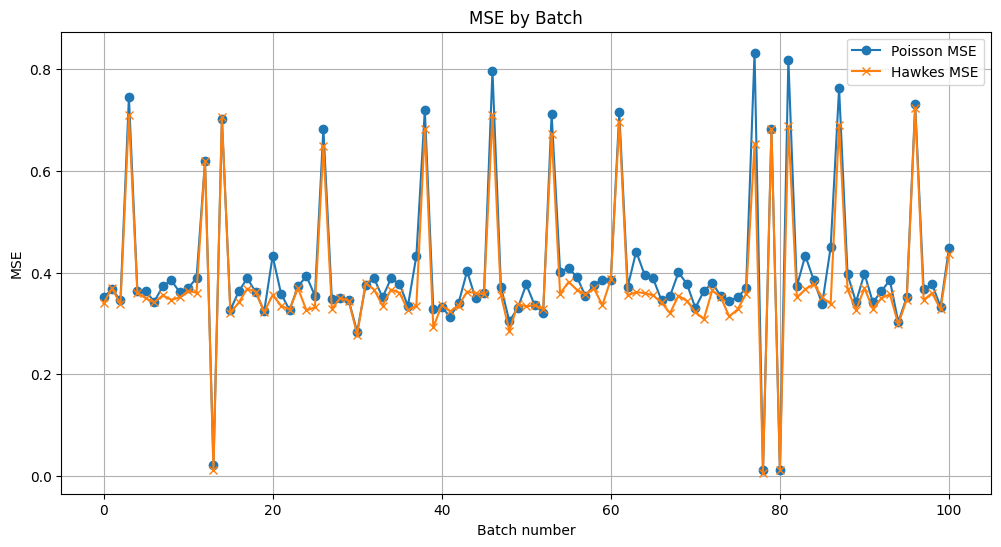

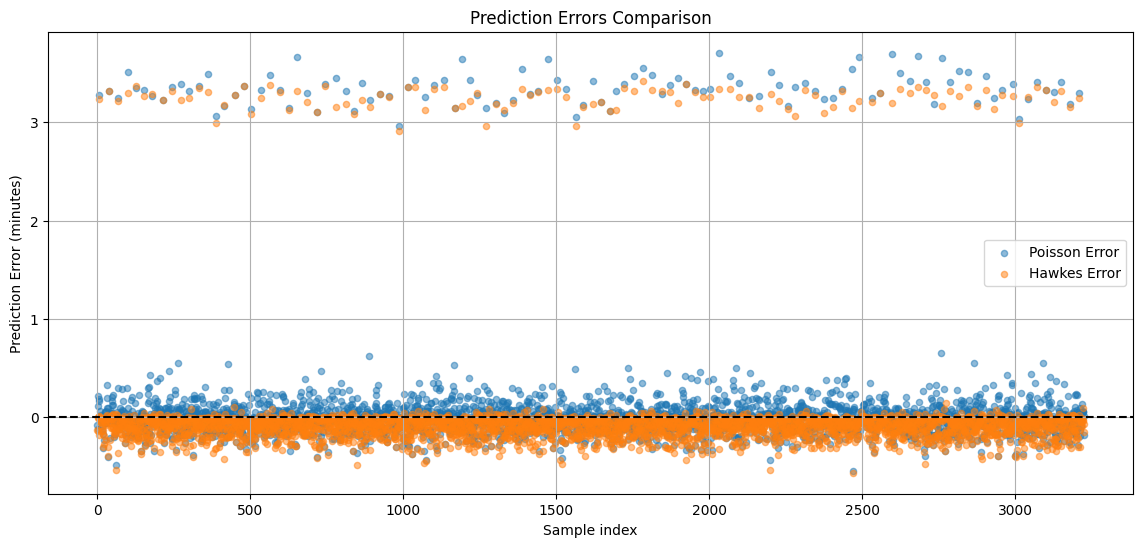

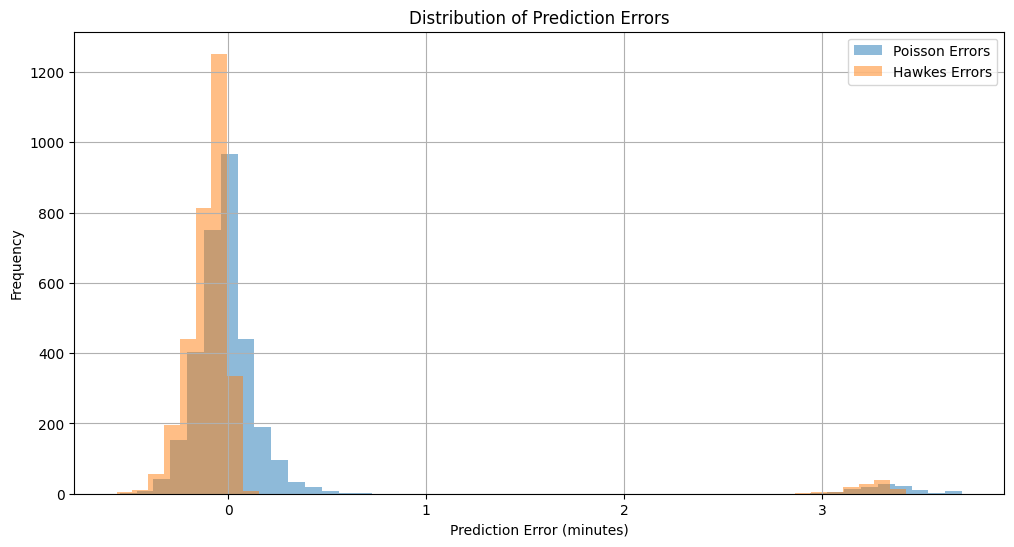

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('output21k.csv')

# Преобразование времени
df[['hours', 'minutes', 'seconds']] = df['Time'].str.split(':', expand=True).astype(int)
df['Time'] = df['hours'] * 60 + df['minutes'] + df['seconds']

# Выбор признаков и нормализация
features = df.drop(columns=['hours', 'minutes', 'seconds']).values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Параметры последовательности
seq_length = 3
batch_size = 32

# Создание последовательностей
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length-1):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(features, seq_length)

# Разделение на train/valid/test
train_size = int(0.7 * len(X))
valid_size = int(0.15 * len(X))
test_size = len(X) - train_size - valid_size

X_test, y_test = X[train_size+valid_size:], y[train_size+valid_size:]

# Преобразование в тензоры PyTorch
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

test_data = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# =============================================================================
# МОДЕЛИ ПРОГНОЗИРОВАНИЯ
# =============================================================================

def predict_next_time_poisson(events, current_time):
    """Улучшенная и защищенная версия пуассоновского процесса"""
    try:
        # Фильтруем события, которые уже произошли
        past_events = np.array([t for t in events if t < current_time])

        # Если нет прошлых событий, используем разумное значение по умолчанию
        if len(past_events) == 0:
            return current_time + 1.0  # Возвращаем минимальный интервал

        # Вычисляем интервалы между событиями
        intervals = np.diff(past_events)

        # Удаляем нулевые или отрицательные интервалы (если есть дубликаты)
        intervals = intervals[intervals > 0]

        # Если нет подходящих интервалов, используем разумное значение по умолчанию
        if len(intervals) == 0:
            return current_time + 1.0

        # Вычисляем средний интервал с защитой от нуля
        mean_interval = np.mean(intervals)
        mean_interval = max(mean_interval, 1e-6)  # Защита от слишком малых значений

        # Генерируем следующее время
        next_time = current_time + np.random.exponential(scale=mean_interval)

        # Защита от аномальных значений
        if next_time <= current_time:
            next_time = current_time + mean_interval

        return next_time

    except Exception as e:
        print(f"Error in Poisson prediction: {e}")
        return current_time + 1.0  # Возвращаем безопасное значение по умолчанию

def predict_next_time_hawkes(events, current_time, mu=0.1, alpha=0.5, beta=1.0):
    """Оптимизированная версия процесса Хоукса"""
    try:
        past_events = np.array([t for t in events if t < current_time])
        t = current_time
        for _ in range(100):
            lambda_t = mu + np.sum(alpha * np.exp(-beta * (t - past_events[past_events < t])))
            dt = np.random.exponential(scale=max(1/lambda_t, 1e-6))
            t_candidate = t + dt
            lambda_candidate = mu + np.sum(alpha * np.exp(-beta * (t_candidate - past_events[past_events < t_candidate])))
            if np.random.rand() < lambda_candidate / max(lambda_t, 1e-6):
                return t_candidate
            t = t_candidate
        return t
    except:
        return current_time + np.random.exponential(scale=1.0)

# =============================================================================
# ФУНКЦИИ ДЛЯ РАСЧЕТА MSE
# =============================================================================

def calculate_mse(actual, predicted):
    """Вычисление MSE между фактическими и прогнозируемыми значениями"""
    return np.mean((actual - predicted)**2)

def inverse_transform_time(times, scaler, n_features):
    """Нормализация временных меток"""
    dummy = np.zeros((len(times), n_features))
    dummy[:, 0] = times
    return scaler.transform(dummy)[:, 0]

# =============================================================================
# ПРОГНОЗИРОВАНИЕ И ОЦЕНКА ПО БАТЧАМ
# =============================================================================

n_features = features.shape[1]
batch_mse_poisson = []
batch_mse_hawkes = []
all_results = []

for batch_idx, (batch_X, batch_y) in enumerate(test_loader):
    # Получаем фактические значения времени для батча
    actual_times = batch_y[:, 0].numpy()
    last_times = batch_X[:, -1, 0].numpy()

    # Прогнозируем для каждого элемента в батче
    poisson_preds = []
    hawkes_preds = []

    for t in last_times:
        poisson_preds.append(predict_next_time_poisson(y_test[:, 0].numpy(), t))
        hawkes_preds.append(predict_next_time_hawkes(y_test[:, 0].numpy(), t))

    # Обратная нормализация
    actual_denorm = inverse_transform_time(actual_times, scaler, n_features)
    poisson_denorm = inverse_transform_time(poisson_preds, scaler, n_features)
    hawkes_denorm = inverse_transform_time(hawkes_preds, scaler, n_features)

    # Вычисляем MSE для батча
    mse_poisson = calculate_mse(actual_denorm, poisson_denorm)
    mse_hawkes = calculate_mse(actual_denorm, hawkes_denorm)

    batch_mse_poisson.append(mse_poisson)
    batch_mse_hawkes.append(mse_hawkes)

    # Сохраняем результаты для визуализации
    for i in range(len(actual_times)):
        all_results.append({
            'batch': batch_idx,
            'actual_time': actual_denorm[i],
            'poisson_pred': poisson_denorm[i],
            'hawkes_pred': hawkes_denorm[i],
            'poisson_error': poisson_denorm[i] - actual_denorm[i],
            'hawkes_error': hawkes_denorm[i] - actual_denorm[i]
        })

    print(f"Batch {batch_idx}: Poisson MSE = {mse_poisson:.2f}, Hawkes MSE = {mse_hawkes:.2f}")

# Общий MSE по всем батчам
total_mse_poisson = np.mean(batch_mse_poisson)
total_mse_hawkes = np.mean(batch_mse_hawkes)
print(f"\nFinal MSE: Poisson = {total_mse_poisson:.2f}, Hawkes = {total_mse_hawkes:.2f}")

# =============================================================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# =============================================================================

# Конвертируем результаты в DataFrame
results_df = pd.DataFrame(all_results)

# График MSE по батчам
plt.figure(figsize=(12, 6))
plt.plot(batch_mse_poisson, label='Poisson MSE', marker='o')
plt.plot(batch_mse_hawkes, label='Hawkes MSE', marker='x')
plt.xlabel('Batch number')
plt.ylabel('MSE')
plt.title('MSE by Batch')
plt.legend()
plt.grid(True)
plt.show()

# График ошибок прогнозирования
plt.figure(figsize=(14, 6))
plt.scatter(results_df.index, results_df['poisson_error'],
            label='Poisson Error', alpha=0.5, s=20)
plt.scatter(results_df.index, results_df['hawkes_error'],
            label='Hawkes Error', alpha=0.5, s=20)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Sample index')
plt.ylabel('Prediction Error (minutes)')
plt.title('Prediction Errors Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Гистограмма распределения ошибок
plt.figure(figsize=(12, 6))
plt.hist(results_df['poisson_error'], bins=50, alpha=0.5, label='Poisson Errors')
plt.hist(results_df['hawkes_error'], bins=50, alpha=0.5, label='Hawkes Errors')
plt.xlabel('Prediction Error (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.legend()
plt.grid(True)
plt.show()